In [7]:
import pandas
import sqlalchemy
import matplotlib.pyplot as plt

In [8]:
engine = sqlalchemy.create_engine('sqlite:///../power.db')

In [30]:
sql = "SELECT timestamp, power FROM pv WHERE timestamp > '2000-04-12 08:00'"
df = pandas.read_sql(sql, engine)
df['timestamp'] = pandas.to_datetime(df['timestamp'], format='ISO8601')
df.set_index('timestamp', inplace=True)

<Axes: xlabel='timestamp'>

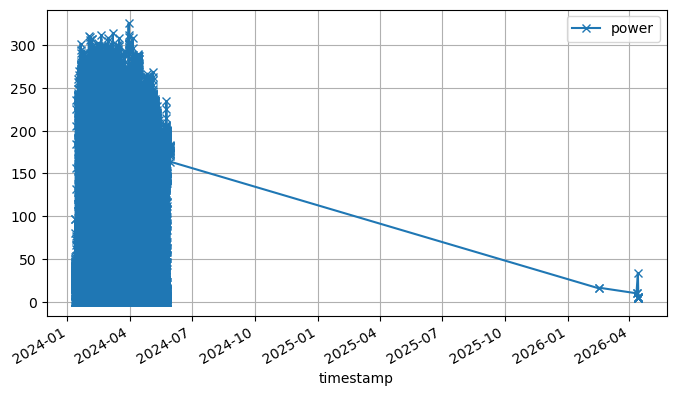

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df.plot(ax=ax, grid=True, marker='x')

In [32]:
energy = df.resample('15min').mean()['power'].sum() / 4
energy

np.float64(175263.52009027777)

# Alltime - After replacing pannels

In [41]:
df_all = pandas.read_sql("select timestamp, power from pv where timestamp>'2026-04-01'", engine)
df_all['timestamp'] = pandas.to_datetime(df_all['timestamp'], format='ISO8601')
df_all.set_index('timestamp', inplace=True)

<Axes: xlabel='hour_of_day'>

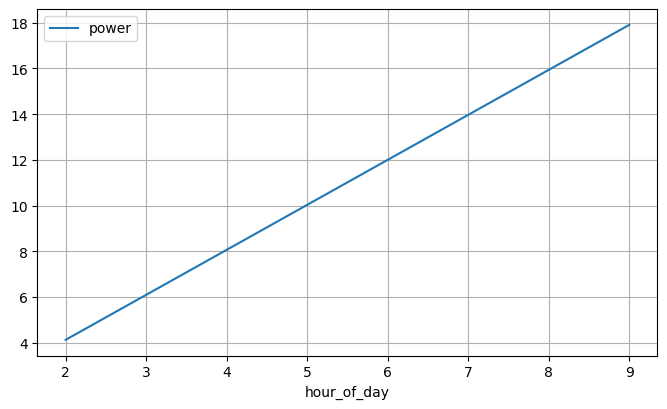

In [42]:
fig, ax = plt.subplots(figsize=(8, 4.5))

df_all['hour_of_day'] = df_all.index.hour
df_all.groupby('hour_of_day').mean().plot(ax=ax, grid=True)

In [10]:
df_all['15_min_chunk'] = (df_all.index.hour * 60 + df_all.index.minute) // 15

Text(0, 0.5, 'Energy in kWh')

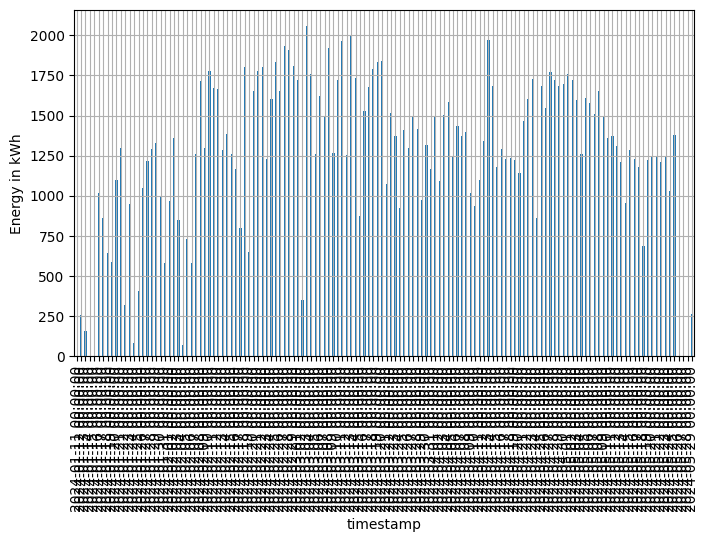

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))

(df_all['power'].resample('1D').sum()/12).plot.bar(ax=ax, grid=True)
ax.set_ylabel("Energy in kWh")

Text(0, 0.5, 'Energy in kWh')

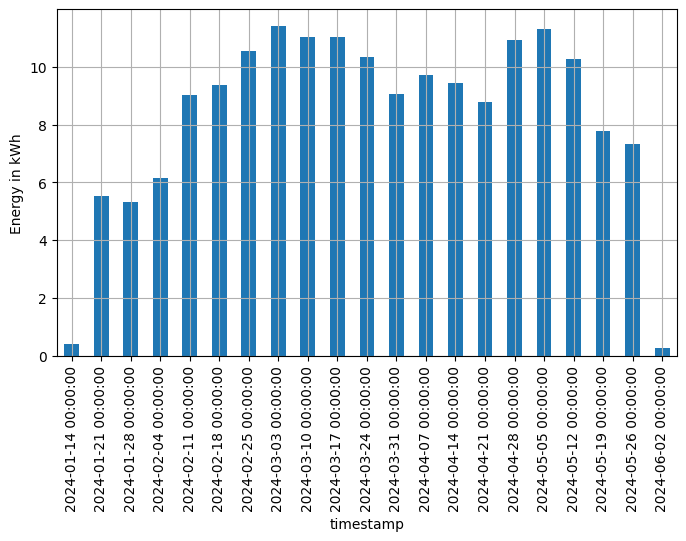

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))

(df_all['power'].resample('1W').sum()/12/1000).plot.bar(ax=ax, grid=True)
ax.set_ylabel("Energy in kWh")

Text(0, 0.5, 'Energy in kWh')

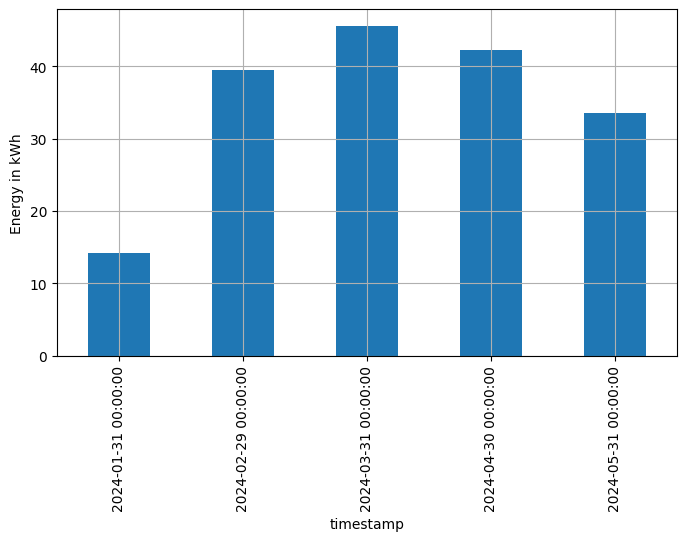

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))

(df_all['power'].resample('1M').sum()/12/1000).plot.bar(ax=ax, grid=True)
ax.set_ylabel("Energy in kWh")

In [14]:
energy = df_all.resample('15T').mean()['power'].sum() / 4
energy / 1000

175.20674464583334